In [1]:
import pandas as pd

In [2]:
evidences = pd.read_json("/content/drive/MyDrive/Disease_engine_project/release_evidences.json") #Path where the file is located

In [4]:
evidences = evidences.T.reset_index(drop=True)

In [5]:
evidences = evidences[["name", "default_value", "possible-values", "data_type"]]

In [8]:
evidences.shape

(223, 4)

In [9]:
features = {}
features["Diagnosis"] = []
features["Age"] = []
for i in range(0, evidences.shape[0]):
  if not evidences.iloc[i, 2]:
    features[evidences.iloc[i, 0]] = []
  else:
    for j in evidences.iloc[i, 2]:
      features[evidences.iloc[i,0] + "_" + str(j)] = []

In [10]:
feature_df = pd.DataFrame(features)

In [11]:
feature_df

,Diagnosis,Age,E_91,E_55_V_123,E_55_V_14,E_55_V_15,E_55_V_16,E_55_V_17,E_55_V_18,E_55_V_19,...,E_200,E_199,E_121,E_120,E_142,E_195,E_183,E_224,E_223,E_5


The previous cells created our dataframe holding all the features that will be used for the model

In [12]:
data = pd.read_csv("/content/drive/MyDrive/Disease_engine_project/release_train_patients_pipe_split", sep='|')

In [14]:
data["AGE"].isnull().sum()

np.int64(0)

In [15]:
print(f"Minimum age: {data["AGE"].min()} - Maximum age: {data["AGE"].max()}")

Minimum age: 0 - Maximum age: 109


In [16]:
data_sum = data.groupby("AGE").count().reset_index()


In [17]:
import matplotlib.pyplot as plt

<BarContainer object of 110 artists>

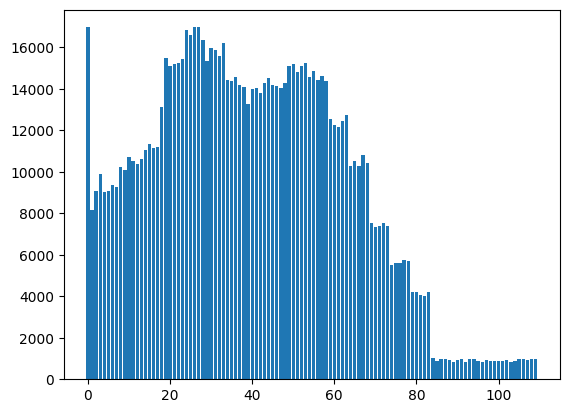

In [18]:
plt.bar(data_sum["AGE"], data_sum["PATHOLOGY"])
#As we can see from the previous analytics, there are no age outliars or null values

In [19]:
data["PATHOLOGY"].isnull().sum()

np.int64(0)

In [20]:
data["EVIDENCES"].isnull().sum()

np.int64(0)

From the previous cells we can notice that there are no missing values in our columns of interest nor dummy values that represent missing values.

In [21]:
data.shape

(1025602, 6)

In [22]:
data = data[["AGE", "PATHOLOGY", "EVIDENCES"]]

In [25]:
data["EVIDENCES"] = data["EVIDENCES"].str.replace(r'(\'| |\[|\]|@_)', '', regex=True).str.split(',')
# Transforms the string formats into the same as the features in the feature dataset, casts the string into an array

In [27]:
data.iloc[0,2][1]

'E_50'

In [ ]:
new_df = feature_df.iloc[:,:]
new_rows = [new_df]
for i in range(700001, data.shape[0]): #Last checkpoint starts at part 10001
  data_row = data.iloc[i, :]
  evidences = data_row[2]
  disease = [data_row[1]]
  age = data_row[0]
  row = {}
  row["Age"] = [int(age)]
  row["Diagnosis"] = disease
  for j in evidences:
    row[j] = [1]
  evidences = []
  new_rows.append(pd.DataFrame(row))
  if i % 10000 == 0 and i != 0:
    concat_df = pd.concat(new_rows, ignore_index=True).fillna(0)
    new_rows = [new_df]
    concat_df.to_parquet("/content/drive/MyDrive/Disease_engine_project/processed_data/output_" + str(i) + ".parquet", engine='pyarrow')
    print(f"Still Going: {i}")

In [43]:
vectors = pd.read_parquet("/content/drive/MyDrive/Disease_engine_project/processed_data/output_1020000.parquet", engine='pyarrow')

In [44]:
for i in vectors.drop(columns=["Diagnosis", "Age"]).columns:
  if (vectors[i].sum() > 0):
    print(f"{i} -> {vectors[i].sum()}\n")

E_91 -> 320.0

E_55_V_123 -> 210.0

E_55_V_25 -> 131.0

E_55_V_29 -> 758.0

E_55_V_32 -> 1659.0

E_55_V_47 -> 13.0

E_55_V_48 -> 7.0

E_55_V_62 -> 148.0

E_55_V_63 -> 836.0

E_55_V_64 -> 776.0

E_55_V_65 -> 649.0

E_55_V_66 -> 532.0

E_55_V_67 -> 822.0

E_55_V_68 -> 801.0

E_55_V_69 -> 806.0

E_55_V_70 -> 796.0

E_55_V_74 -> 193.0

E_55_V_75 -> 118.0

E_55_V_80 -> 75.0

E_55_V_81 -> 36.0

E_55_V_84 -> 565.0

E_55_V_85 -> 502.0

E_55_V_89 -> 1822.0

E_55_V_92 -> 19.0

E_55_V_93 -> 14.0

E_55_V_99 -> 1.0

E_55_V_101 -> 751.0

E_55_V_103 -> 359.0

E_55_V_104 -> 244.0

E_55_V_108 -> 1700.0

E_55_V_109 -> 1683.0

E_55_V_122 -> 1673.0

E_55_V_125 -> 1268.0

E_55_V_126 -> 819.0

E_55_V_151 -> 1.0

E_55_V_166 -> 390.0

E_55_V_167 -> 249.0

E_55_V_187 -> 671.0

E_55_V_194 -> 363.0

E_55_V_195 -> 282.0

E_55_V_197 -> 797.0

E_53 -> 5162.0

E_57_V_123 -> 2118.0

E_57_V_25 -> 1489.0

E_57_V_39 -> 766.0

E_57_V_89 -> 1583.0

E_57_V_122 -> 1533.0

E_57_V_127 -> 766.0

E_57_V_128 -> 785.0

E_57_V_166

The code above shows all the evidences that are present in the last processed chunk of the processed dataset